# Quick introduction to generating counterfactual explanations using DiCE

Exploring "what-if" scenarios is an important way to inspect a machine learning (ML) model. The DiCE library helps you to understand an ML model by generating "what-if" data points that lead to the desired model output. Formally, such "what-if" data points are known as *counterfactuals*, described by the following question:
> Given that the model's output for input $x$ is $y$, what would be the output if input $x$ is changed to $x'$?

The answer to the above question can be obtained by simply inputting $x'$ to the ML model. However, in many cases, we are interested in the reverse question: what changes to $x$ would lead to a desired change in model's output? When inspecting a classifier, for instance, we are often interested in knowing the changes to $x$ that will lead to a desired predicted class. For a regressor, we may be interested in the changes to $x$ that lead to a desired output range. Ideally, these changes should be *proximal* to bring out the local decision logic of the classifier, *sparse* to highlight a limited set of features, and *diverse* to show the different ways in which the same outcome can be achieved. The DiCE library provides an easy interface to generate such counterfactual examples for any ML model.

In addition to proximity (minimal changes) and diversity, another important metric for counterfactual examples is their **feasibility**. If the changes in a counterfactual example are not feasible (e.g., outside the possible range of a particular feature), then the example is less useful. Specifying the possible ranges for continuous features (and possible values for categorical features) is one of the simplest forms of feasibility. DiCE allows you to customize the permitted values for features through the `permitted_range` parameter. In general, feasibility is a complex concept based on whether the [*changes* indicated by a counterfactual are feasible](https://arxiv.org/abs/1912.03277) for the individual, not just that certain values are feasible (e.g., 20 years may be a feasible value for Age feature, but changing a person's age from 22 to 20 is not feasible). DiCE will support such constraints in a future release.

Counterfactual examples generated by DiCE are closely related to **necessity** and **sufficiency** conditions for causing a given model output. Necessity and sufficiency provide an intuitive way to explain a model's output. Given an input $x$ and the model output $y$, a feature value $x_i$ is *necessary* for causing the model output $y$ if changing $x_i$ changes the model output, while keeping every other feature constant. Similarly, a feature value $x_i$ is *sufficient* for causing the model output $y$ if it is impossible to change the model output while keeping $x_i$ constant. DiCE allows inspecting necessity and sufficiency by setting the `features_to_vary` parameter. If `features_to_vary` is set to $x_i$, then the generated counterfactuals demonstrate the necessity of the feature. If `features_to_vary` is set to all features except $x_i$, then the absence of any counterfactuals demonstrates the sufficiency of the feature. In practice, a single feature may be neither sufficient nor necessary---the formal definitions and the `features_to_vary` parameter translate easily to sets of features.

Finally, the counterfactuals for an input data point can be used to derive a **local importance score** for each feature. The local feature importance score ranks features by their frequency of being changed in the generated counterfactuals. Among all the features, necessary features are likely to be changed more often to generate proximal counterfactuals and therefore will receive a higher score. You can use `features_to_vary` and `permitted_range` parameteres to refine the search space for the counterfactuals and consequently, the local importance score. Given a set of input points, the local importance score can be aggregated to provide a global importance score. Compared to explanation methods like LIME or SHAP, feature importance scores generated by DiCE tend to give importance to a larger number of features; more details are in this [paper](https://arxiv.org/abs/2011.04917).

To generate counterfactuals, DiCE implements two kinds of methods: model-agnostic and gradient-based. 

* **Model-Agnostic**: These methods apply to any black-box classifier or regressor. They are based on sampling nearby points to an input point, while optimizing a loss function based on proximity (and optionally, sparsity, diversity and feasibility). Use this class of methods for sklearn models. Currently supported methods are:
    * Randomized Search
    * Genetic Search
    * KD Tree Search (for counterfactuals from a given training dataset)
* **Gradient-Based**: These methods apply to differentiable models, such as those returned by deep learning libraries like tensorflow and pytorch. They are based on an explicit loss minimization based on proximity, diversity and feasibility. The method is described in this [paper](https://arxiv.org/abs/1905.07697).

![DiCE API](images/dice_getting_started_api.png)

DiCE requires two inputs: a training dataset and a pre-trained ML model. When the training dataset is unknown (e.g., for privacy reasons), it can also work without access to the full dataset (see this [notebook](DiCE_with_private_data.ipynb) for an example). Below we show a simple example. 

In [1]:
import sys
dice_path = "/Users/volk/Documents/bau24-25/thesis/repos/DiCE-X"
sys.path.insert(0, dice_path)

In [2]:
# Sklearn imports
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# DiCE imports
import dice_ml_x
from dice_ml_x.utils import helpers  # helper functions

In [3]:
%load_ext autoreload
%autoreload 2

## Preliminaries: Loading a dataset and a ML model trained over it
### Loading the `Adult` dataset

We use the "adult" income dataset from UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/adult). For demonstration purposes, we transform the data as described in **dice_ml.utils.helpers** module. 

In [4]:
dataset = helpers.load_adult_income_dataset()

In [5]:
dataset.head()

,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,28,Private,Bachelors,Single,White-Collar,White,Female,60,0
1,30,Self-Employed,Assoc,Married,Professional,White,Male,65,1
2,32,Private,Some-college,Married,White-Collar,White,Male,50,0
3,20,Private,Some-college,Single,Service,White,Female,35,0
4,41,Self-Employed,Some-college,Married,White-Collar,White,Male,50,0


In [6]:
# description of transformed features
adult_info = helpers.get_adult_data_info()
adult_info

{'age': 'age',
 'workclass': 'type of industry (Government, Other/Unknown, Private, Self-Employed)',
 'education': 'education level (Assoc, Bachelors, Doctorate, HS-grad, Masters, Prof-school, School, Some-college)',
 'marital_status': 'marital status (Divorced, Married, Separated, Single, Widowed)',
 'occupation': 'occupation (Blue-Collar, Other/Unknown, Professional, Sales, Service, White-Collar)',
 'race': 'white or other race?',
 'gender': 'male or female?',
 'hours_per_week': 'total work hours per week',
 'income': '0 (<=50K) vs 1 (>50K)'}

Split the dataset into train and test sets.

In [7]:
target = dataset["income"]
train_dataset, test_dataset, y_train, y_test = train_test_split(dataset,
                                                                target,
                                                                test_size=0.2,
                                                                random_state=0,
                                                                stratify=target)
x_train = train_dataset.drop('income', axis=1)
x_test = test_dataset.drop('income', axis=1)

Given the train dataset, we construct a data object for DiCE. Since continuous and discrete features have different ways of perturbation, we need to specify the names of the continuous features. DiCE also requires the name of the output variable that the ML model will predict.

In [8]:
# Step 1: dice_ml.Data
d = dice_ml_x.Data(dataframe=train_dataset, continuous_features=['age', 'hours_per_week'], outcome_name='income')

### Loading the ML model

DiCE supports sklearn, tensorflow and pytorch models. 

The variable *backend* below indicates the implementation type of DiCE we want to use. Four backends are supported: sklearn, TensorFlow 1.x with backend='TF1', Tensorflow 2.x with backend='TF2', and PyTorch with backend='PYT'. 

Below we show use a trained classification model using sklearn. 

In [9]:
numerical = ["age", "hours_per_week"]
categorical = x_train.columns.difference(numerical)

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

transformations = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical)])

# Append classifier to preprocessing pipeline.
# Now we have a full prediction pipeline.
clf = Pipeline(steps=[('preprocessor', transformations),
                      ('classifier', RandomForestClassifier())])
model = clf.fit(x_train, y_train)

## Generating counterfactual examples using DiCE

We now initialize the DiCE explainer, which needs a dataset and a model. DiCE provides local explanation for the model *m* and requires an query input whose outcome needs to be explained. 

In [10]:
# Using sklearn backend
m = dice_ml_x.Model(model=model, backend="sklearn")
# Using method=random for generating CFs
exp = dice_ml_x.DiceX(d, m, method="genetic")

The `method` parameter specifies the explanation method. DiCE supports three methods for sklearn models: random sampling, genetic algorithm search, and kd-tree based generation.  

The next code snippet shows how to generate and visualize counterfactuals. The first argument of the `generate_counterfactuals` method is the _query instances_ on which counterfactuals are desired. This can be a dataframe with one or more rows. 

Below we provide a sample input whose outcome is 0 (low-income) as per the ML model object *m*. Given the query input, we can now generate counterfactual explanations to show perturbed inputs from the original input where the ML model outputs class 1 (high-income). The last column shows the output of the classifier: `income-output` >=0.5 is class 1 and `income-output`<0.5 is class 0. 

In [11]:
cat_features = {}
for col in categorical:
    if col in dataset.columns:
        cat_features[col] = dataset[col].unique().tolist()
cat_features

{'education': ['Bachelors',
  'Assoc',
  'Some-college',
  'School',
  'HS-grad',
  'Masters',
  'Prof-school',
  'Doctorate'],
 'gender': ['Female', 'Male'],
 'marital_status': ['Single', 'Married', 'Divorced', 'Widowed', 'Separated'],
 'occupation': ['White-Collar',
  'Professional',
  'Service',
  'Blue-Collar',
  'Other/Unknown',
  'Sales'],
 'race': ['White', 'Other'],
 'workclass': ['Private', 'Self-Employed', 'Other/Unknown', 'Government']}

In [12]:
x_test.head()

,age,workclass,education,marital_status,occupation,race,gender,hours_per_week
14946,29,Private,HS-grad,Married,Blue-Collar,White,Female,38
24228,50,Other/Unknown,Some-college,Married,Other/Unknown,White,Male,40
605,50,Private,Bachelors,Married,Professional,White,Male,40
6238,41,Private,School,Married,Blue-Collar,White,Male,30
25954,28,Other/Unknown,Assoc,Separated,Other/Unknown,White,Female,40


In [15]:
gaussian_kwargs = {
    'continuous_features': numerical,
    'categorical_features': cat_features,
    'std_dev': 0.3
}

random_kwargs = {
    'continuous_features': numerical,
    'categorical_features': cat_features,
    'feature_ranges': exp.data_interface.get_features_range_float()[1]
}

spherical_kwargs = {
    'continuous_features': numerical,
    'categorical_features': cat_features,
    'feature_ranges': exp.data_interface.get_features_range_float()[1]
}

e1 = exp.generate_counterfactuals(x_test[0:1], total_CFs=5, perturbation_method="gaussian", desired_class="opposite", **gaussian_kwargs)
e1.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [01:13<00:00, 73.30s/it]

Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,29,Private,HS-grad,Married,Blue-Collar,White,Female,38,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,Bachelors,-,-,-,Male,-,1
0,-,-,Bachelors,-,White-Collar,Other,-,-,1
0,30,-,Bachelors,-,Professional,-,-,-,1
0,27,-,Bachelors,-,Sales,-,-,-,1
0,27,-,Assoc,-,Service,-,-,-,1


The `show_only_changes` parameter highlights the changes from the query instance. If you would like to see the full feature values for the counterfactuals, set it to False.

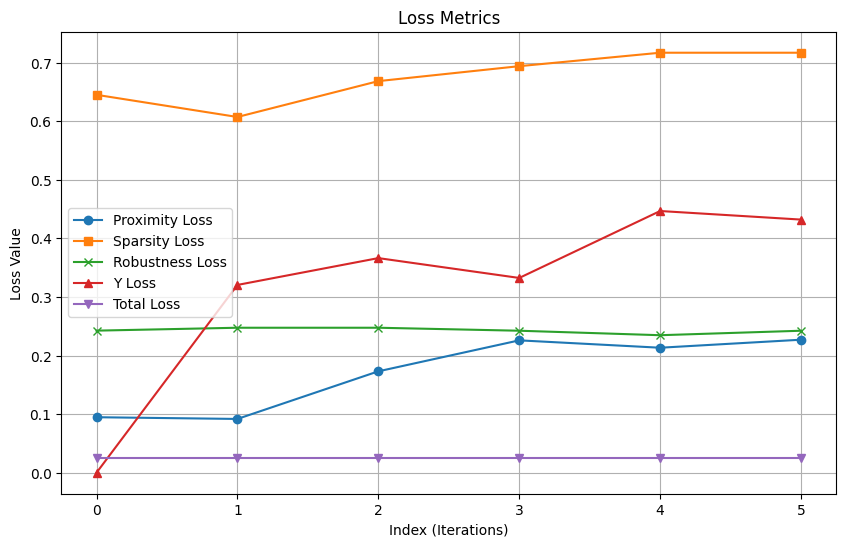

In [64]:
import matplotlib.pyplot as plt

def plot_loss_metrics(loss_metrics):
    """Plots loss metrics over iterations or samples."""
    # Extract metrics
    proximity_loss = loss_metrics["proximity_loss"]
    sparsity_loss = loss_metrics["sparsity_loss"]
    robustness_loss = loss_metrics["robustness_loss"]
    yloss = loss_metrics["y_loss"]
    total_loss = loss_metrics["total_loss"]

    # Create a figure
    plt.figure(figsize=(10, 6))

    # Plot proximity loss
    plt.plot(proximity_loss, label="Proximity Loss", marker='o')

    # Plot sparsity loss
    plt.plot(sparsity_loss, label="Sparsity Loss", marker='s')

    # Plot robustness loss
    plt.plot(robustness_loss, label="Robustness Loss", marker='x')

    # Plot yloss
    plt.plot(yloss, label="Y Loss", marker='^')

    plt.plot(total_loss, label="Total Loss", marker='v')

    # Customize plot
    plt.title("Loss Metrics")
    plt.xlabel("Index (Iterations)")
    plt.ylabel("Loss Value")
    plt.legend()
    plt.grid()

    # Show plot
    plt.show()

plot_loss_metrics(exp.loss_history)

In [36]:
import numpy as np
for item in exp.loss_history:
    for k, v in item.items():
        if type(v) == np.ndarray:
            print(k, " -> ", v.shape)
        else:
            print(k, " -> ", v)

iteration  ->  0
y_loss  ->  0.0
proximity_loss  ->  0.10511442150245622
sparsity_loss  ->  0.65
robustness_loss  ->  0.2375
total_loss  ->  12.301761442150248
iteration  ->  1
y_loss  ->  0.18741113773382892
proximity_loss  ->  0.12302929878369338
sparsity_loss  ->  0.6198979591836735
robustness_loss  ->  0.23469387755102042
total_loss  ->  12.144528906908548
iteration  ->  2
y_loss  ->  0.2451044316950163
proximity_loss  ->  0.19433316679041918
sparsity_loss  ->  0.6785714285714286
robustness_loss  ->  0.2372448979591837
total_loss  ->  12.186118185587777
iteration  ->  3
y_loss  ->  0.18810527757028503
proximity_loss  ->  0.22443583754024574
sparsity_loss  ->  0.675531914893617
robustness_loss  ->  0.2393617021276596
total_loss  ->  11.660113243815765
iteration  ->  4
y_loss  ->  0.38871079233838807
proximity_loss  ->  0.2529300125138118
sparsity_loss  ->  0.7421875
robustness_loss  ->  0.2421875
total_loss  ->  12.019648397420575
iteration  ->  5
y_loss  ->  0.3807156575612526
prox

In [65]:
e1.visualize_as_dataframe(show_only_changes=False)

Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,29,Private,HS-grad,Married,Blue-Collar,White,Female,38,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,30,Private,Bachelors,Married,Professional,White,Female,38,1
0,27,Private,Assoc,Married,Service,White,Female,38,1
0,29,Private,Assoc,Married,Service,White,Female,40,1
0,29,Private,Bachelors,Married,Blue-Collar,White,Male,40,1
0,17,Private,Assoc,Married,White-Collar,White,Female,38,1


That's it! You can try generating counterfactual explanations for other examples using the same code. 
It is also possible to restrict the features to vary while generating the counterfactuals, and to specify permitted range of features within which the counterfactual should be generated. 

In [66]:
{category: rng for category, rng in exp.data_interface.get_features_range()[1].items() if category in exp.data_interface.categorical_feature_names}

{'workclass': ['Private', 'Other/Unknown', 'Self-Employed', 'Government'],
 'education': ['HS-grad',
  'Some-college',
  'Prof-school',
  'School',
  'Bachelors',
  'Masters',
  'Assoc',
  'Doctorate'],
 'marital_status': ['Married', 'Divorced', 'Single', 'Separated', 'Widowed'],
 'occupation': ['Blue-Collar',
  'Other/Unknown',
  'White-Collar',
  'Sales',
  'Service',
  'Professional'],
 'race': ['White', 'Other'],
 'gender': ['Male', 'Female']}

In [67]:
# Changing only age and education
e2 = exp.generate_counterfactuals(x_test[0:1],
                                  total_CFs=5,
                                  desired_class="opposite",
                                  features_to_vary=["education", "occupation"],
                                  perturbation_method="gaussian", **gaussian_kwargs
                                  )
e2.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:34<00:00, 34.52s/it]

Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,29,Private,HS-grad,Married,Blue-Collar,White,Female,38,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,Assoc,-,Service,-,-,-,1
0,-,-,Assoc,-,White-Collar,-,-,-,1
0,-,-,Bachelors,-,Other/Unknown,-,-,-,1
0,-,-,Bachelors,-,Professional,-,-,-,1
0,-,-,Bachelors,-,Sales,-,-,-,1


In [68]:
# Restricting age to be between [20,30] and Education to be either {'Doctorate', 'Prof-school'}.
e3 = exp.generate_counterfactuals(x_test[0:1],
                                  total_CFs=2,
                                  desired_class="opposite",
                                  permitted_range={'age': [20, 30], 'education': ['Doctorate', 'Prof-school']},
                                  perturbation_method="gaussian", **gaussian_kwargs)
e3.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:45<00:00, 45.63s/it]

Query instance (original outcome : 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,29,Private,HS-grad,Married,Blue-Collar,White,Female,38,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,30,-,Prof-school,-,Professional,-,-,-,1
0,30,-,Prof-school,-,Professional,-,Male,-,1


## Generating feature attributions (local and global) using DiCE

DiCE can generate feature importance scores using a summary of the counterfactuals generated. Intuitively, a feature that is changed more often when generating proximal counterfactuals for an input is locally important for causing the model's prediction at the input. Formally, counterfactuals operationalize the __necessity__ criterion for a model explanation: _is the feature value necessary for the given model output?_ 

For more details, refer to the paper, [Towards Unifying Feature Attribution and Counterfactual Explanations: Different Means to the Same End](https://arxiv.org/abs/2011.04917).

### Local feature importance scores

These scores are computed for a given query instance (input point) by summarizing a set of counterfactual examples around the point. 

In [30]:
import tensorflow as tf
tf.constant(x_test[1:5].values, dtype=tf.float32)

ValueError: could not convert string to float: 'Other/Unknown'

In [18]:
query_instance = x_test[0:1]
imp = exp.local_feature_importance(query_instance, total_CFs=10)
print(imp.local_importance)

  0%|          | 0/1 [00:00<?, ?it/s]


TypeError: _generate_counterfactuals() missing 1 required positional argument: 'perturbation_method'

The `total_CFs` parameter denotes the number of counterfactuals that are used to create the local importance. More the better.

### Global feature importance scores

A global importance score per feature can be estimated by aggregating the scores over individual inputs. The more the inputs, the better the estimate for global importance of a feature.

In [19]:
query_instances = x_test[0:20]
imp = exp.global_feature_importance(query_instances)
print(imp.summary_importance)

  0%|          | 0/20 [00:00<?, ?it/s]


TypeError: _generate_counterfactuals() missing 1 required positional argument: 'perturbation_method'

## Working with deep learning models (TensorFlow and PyTorch)

We now show examples of gradient-based methods with Tensorflow and Pytorch models. Since the gradient-based methods _optimize_ the loss rather than simply sampling some points, they can be slower to generate counterfactuals. The loss is defined by three component: **validity** (does the CF have the desired model output), **proximity** (distance of CF from original point should be low), and **diversity** (multiple CFs should change different features). The DiCE loss formulation is described in the paper, [Explaining Machine Learning Classifiers through Diverse Counterfactual Explanations](https://arxiv.org/abs/1905.07697).

Below, we use a pre-trained ML model which produces high accuracy comparable to other baselines. For convenience, we include the sample trained model with the DiCE package.

### Explaining a Tensorflow model

In [31]:
backend = 'TF2'  # needs tensorflow installed
ML_modelpath = helpers.get_adult_income_modelpath(backend=backend)
# Step 2: dice_ml.Model
m = dice_ml_x.Model(model_path=ML_modelpath, backend=backend, func="ohe-min-max")

We want to note that the time required to find counterfactuals with Tensorflow 2.x's eager style of execution is significantly greater than that with TensorFlow 1.x's graph execution.

Based on the data object *d* and the model object *m*, we can now instantiate the DiCE class for generating explanations. 

In [32]:
# Step 3: initiate DiCE
exp = dice_ml_x.DiceX(d, m, method="gradient")

Below we provide query instances from `x_test`.

In [33]:
# generate counterfactuals
dice_exp = exp.generate_counterfactuals(x_test[1:2], total_CFs=4, perturbation_method="gaussian",
                                        desired_class="opposite", **gaussian_kwargs)
# visualize the result, highlight only the changes
dice_exp.visualize_as_dataframe(show_only_changes=True)

Diverse Counterfactuals found! total time taken: 06 min 47 sec
Query instance (original outcome : 0.6710000038146973)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,50.0,Other/Unknown,Some-college,Married,Other/Unknown,White,Male,40.0,0.671



Diverse Counterfactual set (new outcome: 0.0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,-,Single,-,-,-,21.0,0
1,17.0,-,-,-,-,Other,-,-,0
2,62.0,-,School,-,-,-,-,46.0,0
3,-,-,-,Divorced,Blue-Collar,-,-,-,0


The counterfactuals generated above are slightly different from those shown in [our paper](https://arxiv.org/pdf/1905.07697.pdf), where the loss convergence condition was made more conservative for rigorous experimentation. To replicate the results in the paper, add an argument *loss_converge_maxiter=2* (the default value is 1) in the *exp.generate_counterfactuals()* method above. For more info, see *generate_counterfactuals()* method in [dice_ml.dice_interfaces.dice_tensorflow.py](https://github.com/interpretml/DiCE/blob/master/dice_ml/dice_interfaces/dice_tensorflow1.py).

In [19]:
dice_exp.visualize_as_dataframe(show_only_changes=False)

Query instance (original outcome : 0.6710000038146973)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,50.0,Other/Unknown,Some-college,Married,Other/Unknown,White,Male,40.0,0.671



Diverse Counterfactual set (new outcome: 0.0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,50.0,Other/Unknown,Some-college,Single,Other/Unknown,White,Male,24.0,0
1,25.0,Other/Unknown,Some-college,Married,Other/Unknown,Other,Male,40.0,0
2,73.0,Other/Unknown,School,Married,Other/Unknown,White,Male,40.0,0
3,50.0,Other/Unknown,Some-college,Divorced,Blue-Collar,White,Male,46.0,0


### Explaining a Pytorch model

Just change the backend variable to 'PYT' to use DiCE with PyTorch. Below, we use a pre-trained ML model in PyTorch which produces high accuracy comparable to other baselines. For convenience, we include the sample trained model with the DiCE package. Additionally, we need to provide a data transformer function that converts input dataframe into one-hot encoded/numeric format. 

In [10]:
import torch
import numpy as np
t = torch.tensor(np.random.randn(3, 4), dtype=torch.float32)
t

tensor([[-0.8379, -0.5736, -0.2195,  0.0592],
        [ 1.1999,  0.6650, -0.7655,  0.1812],
        [-0.2028,  0.0705,  0.1159,  1.1177]])

In [19]:
backend = 'PYT'  # needs pytorch installed
ML_modelpath = helpers.get_adult_income_modelpath(backend=backend)
m = dice_ml_x.Model(model_path=ML_modelpath, backend=backend,  func="ohe-min-max")

In [29]:
type(exp.model.model)

torch.nn.modules.container.Sequential

Instantiate the DiCE class with the new PyTorch model object *m*. 

In [27]:
exp = dice_ml_x.DiceX(d, m, method="gradient")

In [ ]:
# generate counterfactuals
dice_exp = exp.generate_counterfactuals(x_test[1:2], total_CFs=4, desired_class="opposite",
                                        perturbation_method="gaussian", **gaussian_kwargs)
# highlight only the changes
dice_exp.visualize_as_dataframe(show_only_changes=True)

 50%|█████     | 1/2 [00:57<00:57, 57.99s/it]

Diverse Counterfactuals found! total time taken: 00 min 57 sec


100%|██████████| 2/2 [01:58<00:00, 59.33s/it]

Diverse Counterfactuals found! total time taken: 01 min 00 sec
Query instance (original outcome : 0.6179999709129333)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,50,Other/Unknown,Some-college,Married,Other/Unknown,White,Male,40,0.618


...

,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,38,-,-,-,-,-,-,26,0
1,-,-,-,-,Blue-Collar,-,Female,-,0
2,-,Government,School,-,-,-,-,-,0
3,70,-,-,Divorced,-,Other,-,-,0


Query instance (original outcome : 0.9679999947547913)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,50,Private,Bachelors,Married,Professional,White,Male,40,0.968



Diverse Counterfactual set (new outcome: 0.0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,18,-,-,-,-,-,-,35,0
1,-,-,Some-college,Separated,Service,-,-,-,0
2,69,-,-,Single,-,-,-,-,0
3,-,Other/Unknown,School,-,-,-,Female,-,0


We can also use method-agnostic explainers like "random" or "genetic". 

In [80]:
m = dice_ml_x.Model(model_path=ML_modelpath, backend=backend, func="ohe-min-max")
exp = dice_ml_x.DiceX(d, m, method="random")

In [81]:
# generate counterfactuals
dice_exp = exp.generate_counterfactuals(x_test[1:3], total_CFs=4, desired_class="opposite")
# highlight only the changes
dice_exp.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 2/2 [00:00<00:00,  5.96it/s]

Query instance (original outcome : 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,50,Other/Unknown,Some-college,Married,Other/Unknown,White,Male,40,1



Diverse Counterfactual set (new outcome: 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,School,Separated,-,-,-,-,0
1,-,-,-,-,-,Other,-,11,0
2,-,Private,-,-,-,-,-,9,0
3,-,Self-Employed,School,-,-,-,-,-,0


Query instance (original outcome : 1)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,50,Private,Bachelors,Married,Professional,White,Male,40,1



Diverse Counterfactual set (new outcome: 0)


,age,workclass,education,marital_status,occupation,race,gender,hours_per_week,income
0,-,-,-,Separated,-,-,-,-,0
1,80,-,-,Separated,-,-,-,-,0
2,-,Other/Unknown,-,Divorced,-,-,-,-,0
3,-,Government,-,Widowed,-,-,-,-,0


## More resources: What's next?

DiCE has multiple configurable options and support for different kinds of models. Follow these notebooks to learn more.

1. You can constrain the features to vary, weigh the relative importance of different features for computing distance, or specify permitted ranges for each feature. Check out the [Customizing Counterfactuals Notebook](DiCE_with_advanced_options.ipynb). 
2. You can use it for multi-class classification or regression models. [Counterfactuals for Multi-class Classification and Regression Models Notebook](DiCE_multiclass_classification_and_regression.ipynb).
3. Explore the different model-agnostic explanation methods in DiCE. [Model-agnostic Counterfactual Generation Methods](DiCE_model_agnostic_CFs.ipynb).
4. You can generate CFs even without access to training data (e.g., for privacy-sensitive data). [DiCE with Private Data Notebook](DiCE_with_private_data.ipynb).
5. Feasibility of counterfactuals is an important consideration. You can try out this VAE-based method that adds a CF likelihood term to the loss. [VAE-based Counterfactuals (Pytorch only)](DiCE_getting_started_feasible.ipynb).

